<div style=" background-color: #439cc8;border-radius: 8px;font-size:2.5rem;" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">NOTEBOOK 3</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Modélisation mixte
</h2>
</div>

<div style="background-color: #439cc8;border-radius: 8px;font-size:2rem;" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">1 - Préparation des données</h2>
</div>

<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">1.1 - Import des librairies</h3>
</div>

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">1.2 - Acquisition des données</h3>
</div>

In [2]:
pd.set_option("display.max_columns", 999)
df = pd.read_parquet(r"D:\ENI\CHAPITRE_09\used_cars_germany\data_clean.parquet", engine='pyarrow')
df.head()

,brand,model,color,registration_date,year,power_ps,transmission_type,fuel_type,mileage_in_km,version,price,fuel_consumption_g_km_num,fuel_consumption_l_100km_num,month
0,alfa-romeo,Alfa Romeo 147,blue,2005-10-01,2005,185,Manual,Petrol,126000,Brera,10599,287.0,12.1,10
1,alfa-romeo,Alfa Romeo Spider,blue,2005-06-01,2005,166,Manual,Petrol,203997,2.0 JTS Edizione 2005,5900,220.0,9.2,6
2,alfa-romeo,Alfa Romeo GT,grey,2005-06-01,2005,241,Manual,Petrol,143800,"3.2 V6 24V Distinctive Alfa-Scheckheft,1.Hand",17980,295.0,12.4,6
3,alfa-romeo,Alfa Romeo GT,grey,2005-09-01,2005,166,Manual,Petrol,219000,2.0 16V JTS Distinctive Leder Bose LM ATM,2000,207.0,8.7,9
4,alfa-romeo,Alfa Romeo GT,grey,2005-10-01,2005,241,Manual,Petrol,130260,"3.2 V6 24V Distinctive, LEDER, aAC, TEMPO,PDC",7990,295.0,12.4,10


<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">1.3 - Filtrage des données</h3>
</div>

In [3]:
# Comptage des occurrences de chaque marque
brand_counts = df['brand'].value_counts()

# Filtrage des marques avec plus de 50 occurrences
brands_above_50 = brand_counts[brand_counts > 50].index.tolist()

# Filtrage des données
df = df[df['brand'].isin(brands_above_50)].copy()


<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">1.4 - Gestion des variables textuelles</h3>
</div>

<div style="width: 50%; border-bottom: 1px solid #439cc8;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">1.4.1 - Création de la variable vehicule</h4>
</div>

In [4]:
# Concaténation des colonnes textuelles en 'vehicule'
vars_txt = ['model', 'version', 'color', 'transmission_type', 'fuel_type']
df['vehicule'] = df[vars_txt].agg(' '.join, axis=1)

# Comblement des vides
df['vehicule'] = df['vehicule'].fillna('')

# Suppression des anciennes variables
df.drop(["brand"] + vars_txt,axis=1,inplace=True)

In [5]:
df.head(2)

,registration_date,year,power_ps,mileage_in_km,price,fuel_consumption_g_km_num,fuel_consumption_l_100km_num,month,vehicule
0,2005-10-01,2005,185,126000,10599,287.0,12.1,10,Alfa Romeo 147 Brera blue Manual Petrol
1,2005-06-01,2005,166,203997,5900,220.0,9.2,6,Alfa Romeo Spider 2.0 JTS Edizione 2005 blue M...


<div style="width: 50%; border-bottom: 1px solid #439cc8;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">1.4.2 - TFIDF</h4>
</div>

In [6]:
# Utilisation d'un TFIDF
vectorizer = TfidfVectorizer(stop_words=None, # Pas de stopwords car toutes les infos sont utiles
                             max_features=500,
                             min_df=0.005,
                             max_df=0.9)

# Transformation de la variable textuelle en vecteur
vehicule_matrix = vectorizer.fit_transform(df['vehicule'])

In [7]:
print(vehicule_matrix.shape)

(188542, 300)


In [8]:
# Transformation de la colonne 'vehicule' en matrice
vehicule_matrix = vectorizer.fit_transform(df['vehicule'])

# Récupération des mots (features)
words = vectorizer.get_feature_names_out()

# Conversion de la matrice creuse en matrice dense
dense_matrix = vehicule_matrix.toarray()

# Création d'un DataFrame pour mieux visualiser
df_words = pd.DataFrame(dense_matrix, columns=words)

# Afficher le DataFrame pour voir les mots et leurs occurrences
display(df_words)

,0tdi,100,110,116,120,130,140,150,16v,18,180,19,200,220,250,2wd,30,300,320,35,350,360,40,4m,4matic,4motion,4wd,4x4,500,7g,90,a1,a3,a4,a5,a6,acc,active,advantage,ahk,alfa,allure,alu,ambiente,ambition,amg,apple,arona,astra,at,ateca,audi,aut,autom,automatic,automatik,avant,avantgarde,awd,beige,benz,bi,black,blue,blueefficiency,bluehdi,bluemotion,bluetooth,bmt,bmw,bose,brown,bt,business,cabrio,cabriolet,caddy,cam,captur,carplay,cdi,cdti,cee,ceed,citroen,clio,combi,comfort,comfortline,connect,cool,cooper,corolla,corsa,coupe,crdi,cross,crossland,cx,dab,dacia,dci,dct,design,diesel,dig,dpf,drive,dsg,duster,dynamic,eat8,ecoboost,edc,edition,el,electric,elegance,eu6d,euro,exclusive,fabia,fiat,fiesta,focus,ford,fortwo,fr,garantie,gdi,golf,gra,grand,grandland,green,grey,gt,gti,hand,hd,head,highline,hr,hud,hybrid,hyundai,i30,ibiza,ii,in,innovation,insignia,intens,iv,jahre,jeep,kam,kamera,kamiq,karoq,kasten,keyless,kia,klasse,klima,klimaaut,klimaautomatik,kodiaq,kombi,kuga,kw,land,lang,led,leder,leon,life,lim,limited,line,lm,lounge,manual,matrix,max,mazda,megane,mercedes,mini,mokka,momentum,nav,navi,navigation,neu,night,nissan,octavia,one,opel,orange,pack,paket,pano,panorama,passat,pdc,petrol,peugeot,plus,polo,porsche,premium,pro,ps,puretech,q3,qashqai,quattro,range,red,renault,rfk,roc,romeo,rover,rs,rückfahrkamera,sandero,scheckheft,seat,selection,sh,shz,silver,sitze,sitzer,sitzh,sitzheizung,sitzhzg,skoda,skyactiv,smart,sofort,sound,sport,sportage,sportback,sportpaket,sports,st,standheizung,start,stop,stopp,style,superb,sw,tce,tdci,tdi,team,temp,tempo,tempomat,tfsi,tiguan,titanium,top,touran,tourer,touring,toyota,transit,trend,trendline,tronic,tsi,tucson,turbo,turnier,tüv,up,variant,vi,vii,virtual,volkswagen,voll,volvo,vvt,white,winter,x1,xc60,xcellence,xdrive,xenon,yaris,yellow
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.649610,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.314303,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.176630,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.161339,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.649610,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.649610,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.314303,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.1

In [9]:
# Récupérer les mots (features)
words = vectorizer.get_feature_names_out()

# Calculer la moyenne du score TF-IDF de chaque mot (par colonne)
tfidf_scores = np.asarray(vehicule_matrix.mean(axis=0)).flatten()

# Créer un DataFrame pour associer les mots et leur score TF-IDF moyen
df_tfidf_scores = pd.DataFrame({'word': words, 'tfidf_score': tfidf_scores})

# Trier les mots par score TF-IDF (ordre décroissant pour les mots les plus importants)
df_tfidf_sorted = df_tfidf_scores.sort_values(by='tfidf_score', ascending=False)

# Afficher les mots avec le score TF-IDF le plus élevé
print("Mots les plus importants (TF-IDF) :")
display(df_tfidf_sorted.head(10))  # Top 10 des mots avec les scores TF-IDF les plus élevés

# Afficher les mots avec le score TF-IDF le plus bas
print("\nMots les moins importants (TF-IDF) :")
display(df_tfidf_sorted.tail(10))  # Top 10 des mots avec les scores TF-IDF les plus bas

Mots les plus importants (TF-IDF) :


,word,tfidf_score
207,petrol,0.083202
182,manual,0.080143
54,automatic,0.074981
104,diesel,0.065704
192,navi,0.054668
62,black,0.053783
135,grey,0.046352
291,white,0.043324
173,led,0.040934
63,blue,0.036458



Mots les moins importants (TF-IDF) :


,word,tfidf_score
109,duster,0.002540
49,at,0.002487
46,apple,0.002474
111,eat8,0.002472
78,captur,0.002463
113,edc,0.002400
6,140,0.002370
149,in,0.002341
82,cee,0.002190
219,range,0.002069


In [10]:
df_tfidf_scores[df_tfidf_scores['tfidf_score'] > 0.04]

,word,tfidf_score
54,automatic,0.074981
62,black,0.053783
104,diesel,0.065704
135,grey,0.046352
173,led,0.040934
182,manual,0.080143
192,navi,0.054668
207,petrol,0.083202
291,white,0.043324


In [11]:
threshold = 0.001
#low_importance_words = df_tfidf_scores[df_tfidf_scores['tfidf_score'] < threshold]
low_importance_words = df_tfidf_scores[df_tfidf_scores['tfidf_score'] < threshold]
print(f"Nombre de mots avec un score TF-IDF inférieur à {threshold}: {len(low_importance_words)}")

Nombre de mots avec un score TF-IDF inférieur à 0.001: 0


In [12]:
df_tfidf_scores.shape

(300, 2)

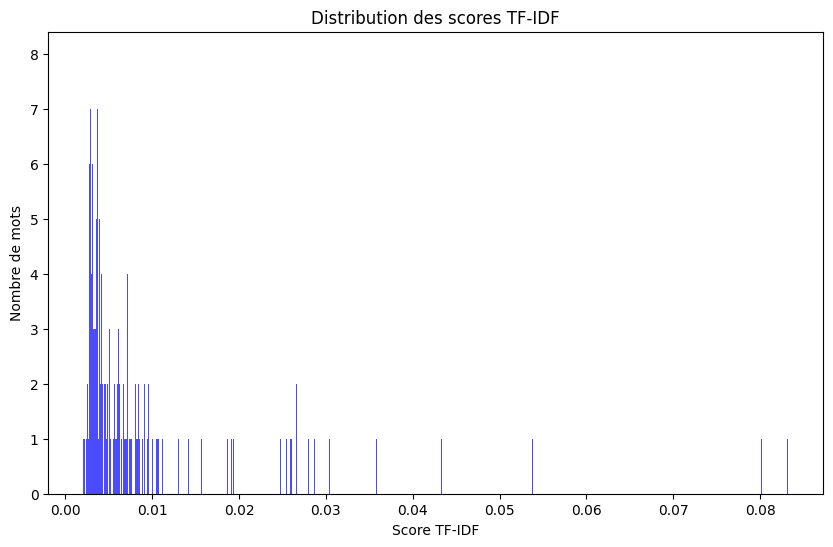

In [13]:
# Tracer un histogramme des scores TF-IDF
plt.figure(figsize=(10, 6))
plt.hist(df_tfidf_scores['tfidf_score'], bins=1500, color='blue', alpha=0.7)
plt.title('Distribution des scores TF-IDF')
plt.xlabel('Score TF-IDF')
plt.ylabel('Nombre de mots')
plt.show()


<div style="background-color: #439cc8;border-radius: 8px;font-size:2rem;" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">2 - Modélisations</h2>
</div>

<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">2.1 - ExtraTreesRegressor</h3>
</div>

In [14]:
from scipy.sparse import hstack
from sklearn.ensemble import ExtraTreesRegressor

In [15]:
# Sélection des variables numériques
numerical_feature_names = ['year',
                           'power_ps', 
                           'fuel_consumption_g_km_num', 
                           'mileage_in_km']

# Concaténation des deux tables
X_combined = hstack([vehicule_matrix, 
                     df[numerical_feature_names]])

# Récupération des mots du TfidfVectorizer
words = vectorizer.get_feature_names_out()

# Combinaison des noms des features textuels et numériques
combined_feature_names = list(words) + numerical_feature_names

# Variable cible
y = df['price']

# Séparation des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X_combined.toarray(), 
                                                    y, 
                                                    test_size=0.3, 
                                                    random_state=42)

In [16]:
# Définition et entraînement du modèle
model = ExtraTreesRegressor(n_estimators=100, 
                            max_depth=None, 
                            random_state=42)

model.fit(X_train, y_train)

# Prédire les valeurs sur l'ensemble de test
y_pred = model.predict(X_test)

# Calculer les performances du modèle
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Afficher les résultats
print(f"ExtraTreesRegressor - RMSE : {rmse:.2f}")
print(f"ExtraTreesRegressor - MAE : {mae:.2f}")
print(f"ExtraTreesRegressor - R² : {r2:.3f}")

ExtraTreesRegressor - RMSE : 3781.83
ExtraTreesRegressor - MAE : 2242.35
ExtraTreesRegressor - R² : 0.894


In [54]:
import seaborn as sns
import matplotlib.pyplot as plt


# Calcul de l'importance des features
feature_importances = model.feature_importances_

# Création d'un DataFrame
importance_df = pd.DataFrame({
    'feature': combined_feature_names,
    'importance': feature_importances})

# Tri par importance décroissante (les 20 premières)
importance_df = importance_df.sort_values(
    by='importance', ascending=False
    )[:20].reset_index(drop=True).copy()




In [55]:
importance_df

,feature,importance
0,year,0.388020
1,power_ps,0.209113
2,manual,0.070761
3,automatic,0.070625
4,mileage_in_km,0.036237
5,fuel_consumption_g_km_num,0.028346
6,diesel,0.013187
7,porsche,0.008328
8,petrol,0.006868
9,benz,0.005769


C:\Users\eric2\AppData\Local\Temp\ipykernel_15280\3939192761.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)


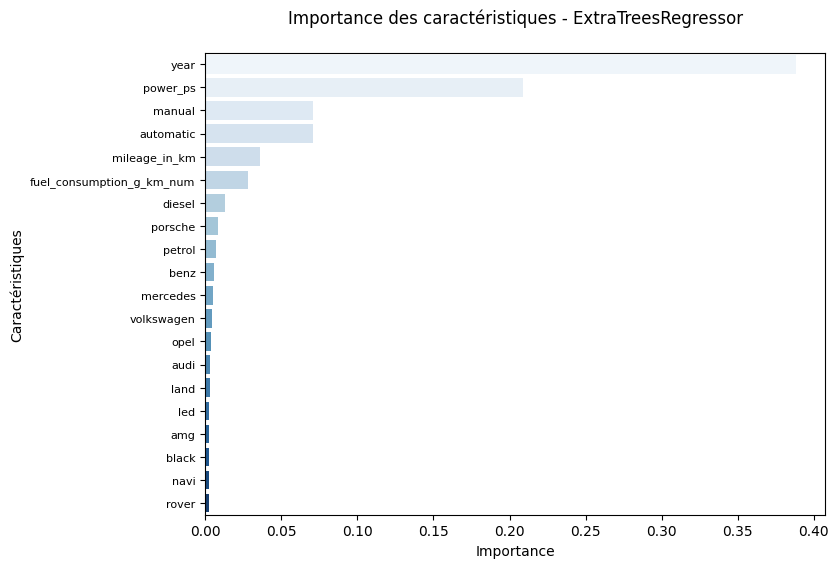

In [64]:

# Visualiser l'importance des caractéristiques avec un bar plot
plt.figure(figsize=(8, 6))

ax = sns.barplot(data=importance_df,x='importance', y='feature',hue='feature',legend=False,palette="Blues")
plt.title('Importance des caractéristiques - ExtraTreesRegressor\n')
plt.xlabel('Importance')
plt.ylabel('Caractéristiques')

# Modifier la taille de la police de l'axe y
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)

plt.show()

In [71]:
import joblib

# Enregistrement du pipeline complet (meilleur modèle)
joblib.dump(model, 'ExtraTreesRegressor.pkl')

# Chargement du pipeline complet plus tard
#model_loaded_ExtraTreesRegressor = joblib.load('model_ExtraTreesRegressor.pkl')

['ExtraTreesRegressor.pkl']

In [ ]:
"""# Séparer la variable cible et les features
y = df['price']

# Diviser les données en ensembles d'entraînement et de test avant toute transformation
# Assurez-vous que vehicule_matrix est la sortie de TfidfVectorizer appliqué à vos données textuelles
X_train_text, X_test_text, X_train_num, X_test_num, y_train, y_test = train_test_split(
    vehicule_matrix, numerical_features, y, test_size=0.3, random_state=42
)

# Normalisation des données numériques de l'ensemble d'entraînement
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_num)

# Appliquer la même transformation à l'ensemble de test
X_test_num_scaled = scaler.transform(X_test_num)

# Combiner les données textuelles (sparse matrix) et les données numériques (déjà normalisées) pour train et test
X_train_combined = hstack([X_train_text, csr_matrix(X_train_num_scaled)])
X_test_combined = hstack([X_test_text, csr_matrix(X_test_num_scaled)])"""



# --------------------- SHAP EXPLANATIONS ---------------------

# Créer un explainer SHAP pour ton modèle
explainer = shap.TreeExplainer(model, X_train)

# Calculer les valeurs SHAP pour l'ensemble de test en désactivant check_additivity
shap_values = explainer(X_test, check_additivity=False)

"""explainer = shap.KernelExplainer(model.predict, X_train)
shap_values = explainer(X_test)"""

# Visualiser l'importance des caractéristiques (summary plot) avec les noms des variables
shap.summary_plot(shap_values, X_test, feature_names=combined_feature_names)


La procédure suivante prend 2H environ

<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">2.2 - RandomForestRegressor</h3>
</div>

In [32]:
# Définir la variable cible (le prix)
y = df['price_in_euro']

# Séparer les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.3, random_state=42)

# Entraîner un modèle de Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Prédire les valeurs sur l'ensemble de test
y_pred = model.predict(X_test)

# Calculer les performances du modèle
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Afficher les résultats
print(f"Random Forest - Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Random Forest - Mean Absolute Error (MAE): {mae:.2f}")
print(f"Random Forest - R-squared (R²): {r2:.3f}")


Random Forest - Mean Squared Error (RMSE): 3758.89
Random Forest - Mean Absolute Error (MAE): 2248.32
Random Forest - R-squared (R²): 0.90


In [33]:
# Récupérer les noms des features
tfidf_feature_names = vectorizer.get_feature_names_out()
numerical_features_names =['year','power_ps', 'fuel_consumption_l_100km', 'mileage_in_km','month']
feature_names = np.hstack([tfidf_feature_names, numerical_features_names])

#feature_names = X.columns

# Récupérer les importances des features
importances = model.feature_importances_

# Créer un DataFrame pour les afficher proprement
df_feature_importances = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Trier les features par importance (ordre décroissant)
df_feature_importances = df_feature_importances.sort_values(by='Importance', ascending=False)

# Afficher les 10 features les plus importantes
print(df_feature_importances.head(60))

                      Feature  Importance
500                      year    0.455800
501                  power_ps    0.316734
503             mileage_in_km    0.042876
502  fuel_consumption_l_100km    0.017525
173                    diesel    0.010391
345                    petrol    0.007355
300                    manual    0.007159
93                  automatic    0.006778
429                        t6    0.004474
308                  mercedes    0.004063
350                   porsche    0.003987
504                     month    0.003759
105                      benz    0.003368
24                        250    0.002354
89                       audi    0.002180
331                      opel    0.002040
479                volkswagen    0.001897
324                      navi    0.001821
108                     black    0.001756
374                     rover    0.001696
428                        t5    0.001529
285                      land    0.001529
207                      ford    0

In [34]:
print(df_feature_importances.tail(10))

       Feature  Importance
420       star    0.000016
226        gse    0.000016
183        eco    0.000016
436  teilleder    0.000014
407  spaceback    0.000014
162        cup    0.000013
98        aygo    0.000012
53          8v    0.000012
176  dolcevita    0.000009
312      micra    0.000006


<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">2.3 - Lightbm</h3>
</div>

In [14]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Définir la variable cible (le prix)
y = df['price']

# Séparer les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.3, random_state=42)

# Entraîner un modèle LightGBM
train_data = lgb.Dataset(X_train, label=y_train)
valid_data = lgb.Dataset(X_test, label=y_test)

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'n_estimators': 100,
    'random_state': 42
}

# Entraînement du modèle LightGBM avec suivi sur l'ensemble de validation
model = lgb.train(params, train_data, num_boost_round=100, valid_sets=[train_data, valid_data])

# Prédire les valeurs sur l'ensemble de test
y_pred = model.predict(X_test, num_iteration=model.best_iteration)

# Calculer les performances du modèle
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Afficher les résultats
print(f"LightGBM - Mean Squared Error (RMSE): {rmse:.2f}")
print(f"LightGBM - Mean Absolute Error (MAE): {mae:.2f}")
print(f"LightGBM - R-squared (R²): {r2:.2f}")


D:\Environnements virtuels\jupyenv310\lib\site-packages\lightgbm\engine.py:204: UserWarning: Found `n_estimators` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.101249 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 76440
[LightGBM] [Info] Number of data points in the train set: 132006, number of used features: 304
[LightGBM] [Info] Start training from score 21340.099405
LightGBM - Mean Squared Error (RMSE): 4126.31
LightGBM - Mean Absolute Error (MAE): 2739.35
LightGBM - R-squared (R²): 0.87


<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">2.4 - HistGradientBoostingRegressor</h3>
</div>

In [15]:
import time
start_time = time.time()

In [16]:
# Rapide
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y = df['price']

# Séparer les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X_combined.toarray(), y, test_size=0.3, random_state=42)

# Entraîner un modèle HistGradientBoosting
model = HistGradientBoostingRegressor(max_iter=100, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

# Prédire les valeurs sur l'ensemble de test
y_pred = model.predict(X_test)

# Calculer les performances du modèle
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Afficher les résultats
print(f"HistGradientBoosting - Mean Squared Error (RMSE): {rmse:.2f}")
print(f"HistGradientBoosting - Mean Absolute Error (MAE): {mae:.2f}")
print(f"HistGradientBoosting - R-squared (R²): {r2:.2f}")


HistGradientBoosting - Mean Squared Error (RMSE): 4129.18
HistGradientBoosting - Mean Absolute Error (MAE): 2739.26
HistGradientBoosting - R-squared (R²): 0.87


In [17]:
end_time = time.time()  # Fin de la mesure
execution_time = end_time - start_time

print(f"Temps d'exécution pour : {execution_time:.2f} secondes")

Temps d'exécution pour : 23.26 secondes


HistGradientBoosting - Mean Squared Error (RMSE): 4129.18
HistGradientBoosting - Mean Absolute Error (MAE): 2739.26
HistGradientBoosting - R-squared (R²): 0.87


100%|===================| 56435/56575 [03:39<00:00]        

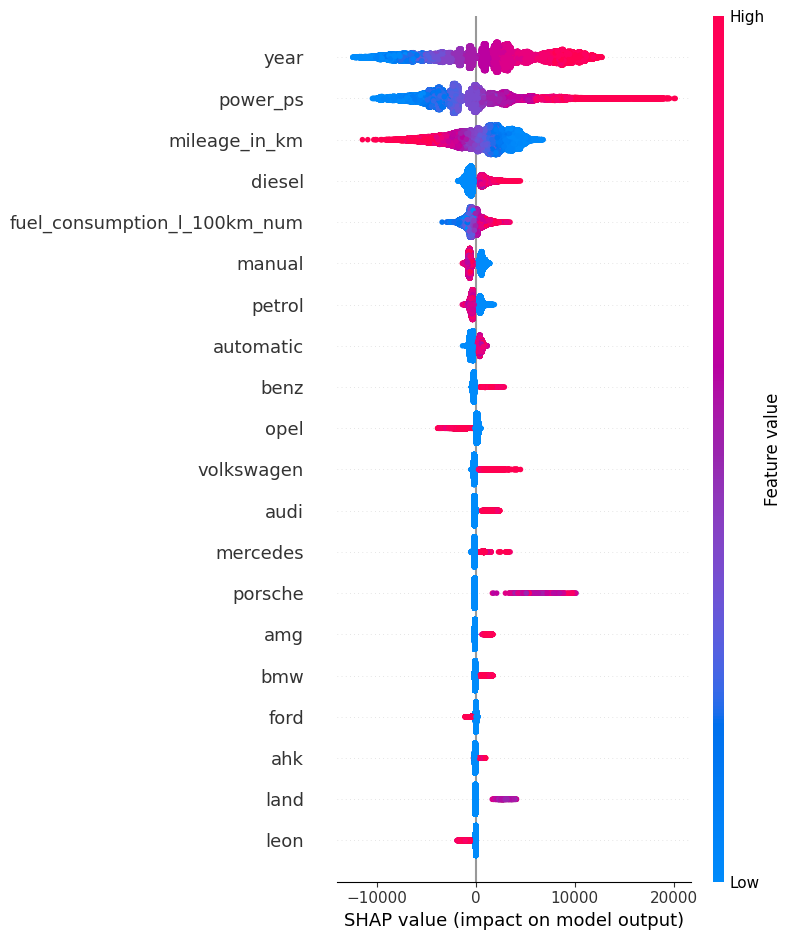

In [18]:
import shap
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack

# Récupérer les mots (features) textuels du TfidfVectorizer
words = vectorizer.get_feature_names_out()

# Récupérer les noms des variables numériques
numerical_feature_names = numerical_features.columns.tolist()

# Combiner les noms des features textuels et numériques
combined_feature_names = list(words) + numerical_feature_names

# Séparer la variable cible et les features
y = df['price']

# Séparer les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X_combined.toarray(), y, test_size=0.3, random_state=42)

# Entraîner un modèle HistGradientBoosting
model = HistGradientBoostingRegressor(max_iter=100, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

# Prédire les valeurs sur l'ensemble de test
y_pred = model.predict(X_test)

# Calculer les performances du modèle
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Afficher les résultats
print(f"HistGradientBoosting - Mean Squared Error (RMSE): {rmse:.2f}")
print(f"HistGradientBoosting - Mean Absolute Error (MAE): {mae:.2f}")
print(f"HistGradientBoosting - R-squared (R²): {r2:.2f}")

# --------------------- SHAP EXPLANATIONS ---------------------

# Créer un explainer SHAP pour ton modèle
explainer = shap.Explainer(model, X_train)

# Calculer les valeurs SHAP pour l'ensemble de test en désactivant check_additivity
shap_values = explainer(X_test, check_additivity=False)

# Visualiser l'importance des caractéristiques (summary plot) avec les noms des variables
shap.summary_plot(shap_values, X_test, feature_names=combined_feature_names)


### Extra trees

44 minutes avec 500 variables issues du TFIDF et 504 variables en tout
10 minutes (620 secondes) avec 162 variables en tout

In [31]:
import time
start_time = time.time()

In [32]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Entraîner un modèle ExtraTrees
model = ExtraTreesRegressor(n_estimators=50,max_depth=None, random_state=42)
model.fit(X_train, y_train)

# Prédire les valeurs sur l'ensemble de test
y_pred = model.predict(X_test) 

# Calculer les performances du modèle
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Afficher les résultats
print(f"ExtraTrees - Mean Squared Error (RMSE): {rmse:.2f}")
print(f"ExtraTrees - Mean Absolute Error (MAE): {mae:.2f}")
print(f"ExtraTrees - R-squared (R²): {r2:.3f}")


ExtraTrees - Mean Squared Error (RMSE): 3798.91
ExtraTrees - Mean Absolute Error (MAE): 2255.80
ExtraTrees - R-squared (R²): 0.893


In [33]:
end_time = time.time()  # Fin de la mesure
execution_time = end_time - start_time

print(f"Temps d'exécution pour : {execution_time:.2f} secondes")

# Pour 50 estimators
# Temps d'exécution pour : 468.24 secondes pour 304 variables MAE : 2255.8

# Pour 100 estimators
# Temps d'exécution pour : 620.30 secondes pour 162 variables
# Temps d'exécution pour : 930.30 secondes pour 304 variables MAE : 2242.35

# Pour 120 estimators
# Temps d'exécution pour : 1198.59 secondes 0.894 MAE : 2240.59

# Pour 150 estimators
# Temps d'exécution pour : 1458.96 secondes 0.894 MAE : 2238.15

Temps d'exécution pour : 468.24 secondes


In [23]:
"""from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Entraîner un modèle AdaBoost avec un arbre de décision comme classificateur de base
base_model = DecisionTreeRegressor(max_depth=3)  # Utiliser un arbre de faible profondeur
model = AdaBoostRegressor(base_estimator=base_model, n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Prédire les valeurs sur l'ensemble de test
y_pred = model.predict(X_test)

# Calculer les performances du modèle
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Afficher les résultats
print(f"AdaBoost - Mean Squared Error (RMSE): {rmse:.2f}")
print(f"AdaBoost - Mean Absolute Error (MAE): {mae:.2f}")
print(f"AdaBoost - R-squared (R²): {r2:.2f}")


AdaBoost - Mean Squared Error (RMSE): 11002.28
AdaBoost - Mean Absolute Error (MAE): 9883.97
AdaBoost - R-squared (R²): 0.10"""


'from sklearn.ensemble import AdaBoostRegressor\nfrom sklearn.tree import DecisionTreeRegressor\nfrom sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score\n\n# Entraîner un modèle AdaBoost avec un arbre de décision comme classificateur de base\nbase_model = DecisionTreeRegressor(max_depth=3)  # Utiliser un arbre de faible profondeur\nmodel = AdaBoostRegressor(base_estimator=base_model, n_estimators=100, random_state=42)\nmodel.fit(X_train, y_train)\n\n# Prédire les valeurs sur l\'ensemble de test\ny_pred = model.predict(X_test)\n\n# Calculer les performances du modèle\nmse = mean_squared_error(y_test, y_pred)\nrmse = np.sqrt(mse)\nmae = mean_absolute_error(y_test, y_pred)\nr2 = r2_score(y_test, y_pred)\n\n# Afficher les résultats\nprint(f"AdaBoost - Mean Squared Error (RMSE): {rmse:.2f}")\nprint(f"AdaBoost - Mean Absolute Error (MAE): {mae:.2f}")\nprint(f"AdaBoost - R-squared (R²): {r2:.2f}")\n\n\nAdaBoost - Mean Squared Error (RMSE): 11002.28\nAdaBoost - Mean Absol

<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">2.5 - BaggingRegressor</h3>
</div>

In [22]:
start_time = time.time()

In [23]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor

# Entraîner un modèle Bagging
base_model = DecisionTreeRegressor()  # Arbre de décision comme modèle de base
model = BaggingRegressor(base_estimator=base_model, n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Prédire les valeurs sur l'ensemble de test
y_pred = model.predict(X_test)

# Calculer les performances du modèle
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Afficher les résultats
print(f"Bagging - Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Bagging - Mean Absolute Error (MAE): {mae:.2f}")
print(f"Bagging - R-squared (R²): {r2:.3f}")


Bagging - Mean Squared Error (RMSE): 3780.23
Bagging - Mean Absolute Error (MAE): 2321.36
Bagging - R-squared (R²): 0.893


In [24]:
end_time = time.time()  # Fin de la mesure
execution_time = end_time - start_time

print(f"Temps d'exécution pour : {execution_time:.2f} secondes")

# Temps d'exécution pour : 490.65 secondes pour 162 variables

Temps d'exécution pour : 575.75 secondes


<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">2.6 - XGBoost</h3>
</div>

In [25]:
start_time = time.time()

In [26]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y = df['price']

# Séparer les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X_combined.toarray(), y, test_size=0.2, random_state=42)

# Entraîner un modèle XGBoost
model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

# Prédire les valeurs sur l'ensemble de test
y_pred = model.predict(X_test)

# Calculer les performances du modèle
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Afficher les résultats
print(f"XGBoost - Mean Squared Error (RMSE): {rmse:.2f}")
print(f"XGBoost - Mean Absolute Error (MAE): {mae:.2f}")
print(f"XGBoost - R-squared (R²): {r2:.3f}")


XGBoost - Mean Squared Error (RMSE): 4183.47
XGBoost - Mean Absolute Error (MAE): 2780.28
XGBoost - R-squared (R²): 0.869


In [27]:
end_time = time.time()  # Fin de la mesure
execution_time = end_time - start_time

print(f"Temps d'exécution pour : {execution_time:.2f} secondes")

# Temps d'exécution pour : 23.65 secondes pour 162 variables

Temps d'exécution pour : 8.09 secondes


<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">2.7 - StackingRegressor</h3>
</div>

In [63]:
start_time = time.time()

In [64]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression

# Définir les modèles de base et le modèle de niveau supérieur
base_models = [
    ('xgb', xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100)),
    ('rf', RandomForestRegressor(n_estimators=100)),
    ('lr', LinearRegression())
]
model = StackingRegressor(estimators=base_models, final_estimator=LinearRegression())

# Entraîner le modèle Stacking
model.fit(X_train, y_train)

# Prédire les valeurs sur l'ensemble de test
y_pred = model.predict(X_test)

# Calculer les performances du modèle
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Afficher les résultats
print(f"Stacking - Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Stacking - Mean Absolute Error (MAE): {mae:.2f}")
print(f"Stacking - R-squared (R²): {r2:.3f}")


Stacking - Mean Squared Error (RMSE): 3771.45
Stacking - Mean Absolute Error (MAE): 2332.85
Stacking - R-squared (R²): 0.894


In [65]:
end_time = time.time()  # Fin de la mesure
execution_time = end_time - start_time

print(f"Temps d'exécution pour : {execution_time:.2f} secondes")

# Temps d'exécution pour : 2231.40 secondes pour 162 variables

Temps d'exécution pour : 2231.40 secondes
